In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

In [28]:
# --- 2. Paths ---
RAW_PATH = Path("../data/raw/lingo-glucose-data-2025-AUG-13.csv")
PROCESSED_PATH = Path("../data/processed/cgm_tokens.json")
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

In [34]:
# --- 3. Load CSV ---
df = pd.read_csv(RAW_PATH)

# rename for easier access
df = df.rename(columns={
    'Time of Glucose Reading [T=(local time) +/- (time zone offset)]': 'timestamp',
    ' Measurement(mg/dL)': 'original_glucose',
})
# convert to datetime & sort
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4023 entries, 2025-07-28 19:00:00-04:00 to 2025-08-11 18:10:00-04:00
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   original_glucose  4023 non-null   object
dtypes: object(1)
memory usage: 62.9+ KB


In [35]:
# --- 4. Resample to 5-min intervals ---
df['original_glucose'] = pd.to_numeric(df['original_glucose'], errors='coerce')
df = df[['original_glucose']].resample('5min').mean()
df['glucose'] = df['original_glucose'].interpolate(method='linear')

# --- 5. Clamp values ---
df['glucose'] = df['glucose'].clip(lower=39, upper=301)

# --- 6. Round + tokenize ---
df['glucose_rounded'] = df['glucose'].round().astype(int)
vocab = {val: i for i, val in enumerate(range(39, 302))}
df['token'] = df['glucose_rounded'].map(vocab)

df.head()


,original_glucose,glucose,glucose_rounded,token
timestamp,,,,
2025-07-28 19:00:00-04:00,75.0,75.0,75,36
2025-07-28 19:05:00-04:00,84.0,84.0,84,45
2025-07-28 19:10:00-04:00,89.0,89.0,89,50
2025-07-28 19:15:00-04:00,96.0,96.0,96,57
2025-07-28 19:20:00-04:00,89.0,89.0,89,50


In [36]:
# --- 7. Save as JSON ---
sequences = df['token'].tolist()
with open(PROCESSED_PATH, 'w') as f:
    json.dump({"input_ids": sequences}, f)
print(f"Saved tokenized CGM sequence to {PROCESSED_PATH}")

Saved tokenized CGM sequence to ../data/processed/cgm_tokens.json


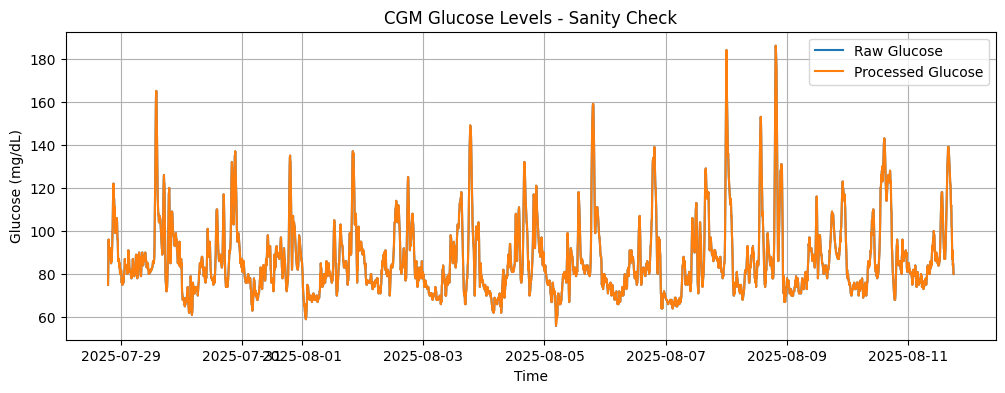

In [41]:
# --- 8. Plot sanity check ---

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['original_glucose'], label='Raw Glucose')
plt.plot(df.index, df['glucose_rounded'], label='Processed Glucose')
plt.title('CGM Glucose Levels - Sanity Check')
plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.legend()
plt.grid()
plt.show()


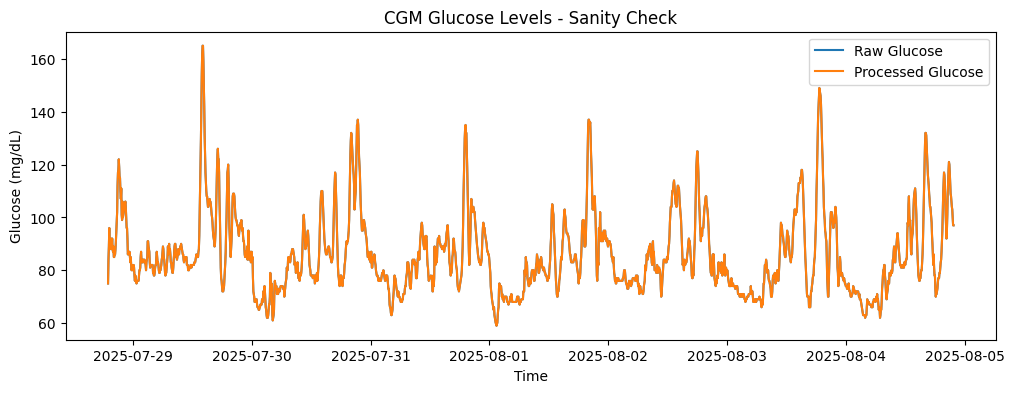

In [ ]:
# --- 8. Plot sanity check ---

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['original_glucose'], label='Raw Glucose')
plt.plot(df.index, df['glucose_rounded'], label='Processed Glucose')
plt.title('CGM Glucose Levels - Sanity Check')
plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.legend()
plt.show()
